In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/shelter_outcomes.csv")
print(df.shape)
df.head()

(173775, 12)


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


In [8]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== TIPOS DE DADOS ===")
print(df.columns.tolist())

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== SHAPE ===
(173775, 12)

=== TIPOS DE DADOS ===
['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']

=== VALORES NULOS ===
Animal ID               0
Date of Birth           0
Name                49784
DateTime                0
MonthYear               0
Outcome Type           46
Outcome Subtype     94115
Animal Type             0
Sex upon Outcome        1
Age upon Outcome        9
Breed                   0
Color                   0
dtype: int64


In [9]:
# Distribuição dos desfechos - nossa variável alvo
print("=== DISTRIBUIÇÃO DE OUTCOME TYPE ===")
print(df["Outcome Type"].value_counts())
print("\n=== PERCENTUAL ===")
print(df["Outcome Type"].value_counts(normalize=True).mul(100).round(2))

=== DISTRIBUIÇÃO DE OUTCOME TYPE ===
Outcome Type
Adoption           84598
Transfer           48689
Return to Owner    25691
Euthanasia         10833
Died                1672
Rto-Adopt           1241
Disposal             877
Missing               92
Relocate              29
Stolen                 5
Lost                   2
Name: count, dtype: int64

=== PERCENTUAL ===
Outcome Type
Adoption           48.70
Transfer           28.03
Return to Owner    14.79
Euthanasia          6.24
Died                0.96
Rto-Adopt           0.71
Disposal            0.50
Missing             0.05
Relocate            0.02
Stolen              0.00
Lost                0.00
Name: proportion, dtype: float64


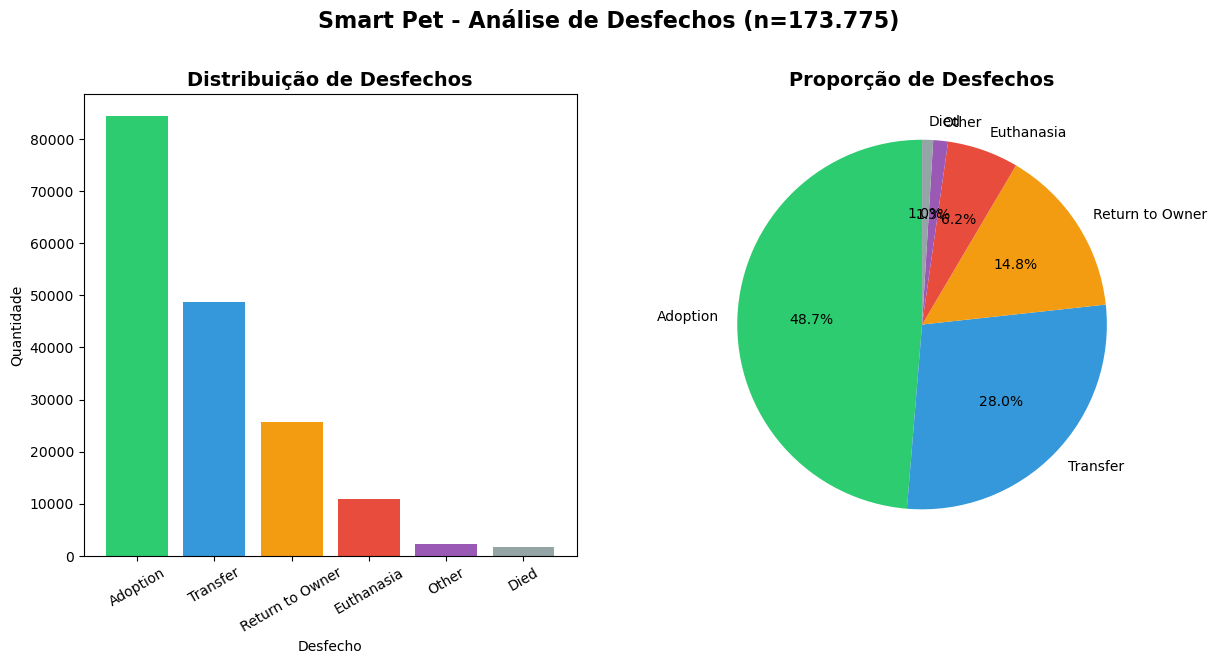

Gráfico salvo em docs/architecture/


In [13]:
# Agrupar por categorias
outcome_map = {
    "Adoption": "Adoption",
    "Transfer": "Transfer",
    "Return to Owner": "Return to Owner",
    "Euthanasia": "Euthanasia",
    "Died": "Died",
    "Rto-Adopt": "Other",
    "Disposal": "Other",
    "Missing": "Other",
    "Relocate": "Other",
    "Stolen": "Other",
    "lost": "Other"
}

df["Outcome Group"] = df["Outcome Type"].map(outcome_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 - Contagem
counts = df["Outcome Group"].value_counts()
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c", "#9b59b6", "#95a5a6",]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Distribuição de Desfechos", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Desfecho")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=30)

# Gráfico 2 - Percentual (pizza)
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Proporção de Desfechos", fontsize=14, fontweight="bold")

plt.suptitle("Smart Pet - Análise de Desfechos (n=173.775)", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("../docs/architecture/eda_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo em docs/architecture/")